# CSI300 Single Backtest Viewer

Auto-discovers the latest single backtest run from either:
- `eval_results/backtest/<run_dir>`
- `eval_results/backtest/ab_pairs/<pair_dir>/run_a|run_b`

Focus:
- single-run summary statistics
- equity curve vs benchmark
- portfolio weights and concentration
- order flow and trading cost totals

This viewer keeps the same structure as `single_backtest_viewer.ipynb`,
but defaults to CSI300-specific runs only.


In [ ]:
from pathlib import Path
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from research.common import map_symbols_to_stock_names

plt.style.use('seaborn-v0_8-whitegrid')

def _resolve_backtest_root() -> Path:
    for c in (Path('eval_results/backtest'), Path('../eval_results/backtest')):
        if c.exists():
            return c
    return Path('eval_results/backtest')

def _is_run_dir(path: Path) -> bool:
    return path.is_dir() and (path / 'summary.json').exists() and (path / 'equity_curve.csv').exists()

def _latest_trade_date(run_dir: Path):
    try:
        eq = pd.read_csv(run_dir / 'equity_curve.csv', usecols=['trade_date'])
        return pd.to_datetime(eq['trade_date']).max()
    except Exception:
        return pd.NaT

def _has_daily_market_value(run_dir: Path) -> bool:
    return (run_dir / 'daily_market_value.csv').exists()

def _is_dated_snapshot_run(run_dir: Path) -> bool:
    name = run_dir.name
    return bool(re.search(r'(?:^|_)(?:19|20)\d{6}(?:$|_)', name) or re.search(r'(?:19|20)\d{2}-\d{2}-\d{2}', name))

def _is_csi300_run(path: Path) -> bool:
    name = path.name.lower()
    if 'csi300' in name:
        return True
    try:
        summary = json.loads((path / 'summary.json').read_text())
        benchmark = str(summary.get('benchmark_symbol', '')).upper()
        return benchmark == 'SH000300'
    except Exception:
        return False

def _collect_runs(root: Path) -> list[dict]:
    runs = []
    if root.exists():
        for p in root.iterdir():
            if p.name == 'ab_pairs':
                continue
            if _is_run_dir(p) and _is_csi300_run(p):
                runs.append({'run_dir': p, 'source': 'single', 'pair': None})

    pair_root = root / 'ab_pairs'
    if pair_root.exists():
        for pair in pair_root.iterdir():
            if not pair.is_dir():
                continue
            for child in ('run_a', 'run_b'):
                rp = pair / child
                if _is_run_dir(rp) and _is_csi300_run(rp):
                    runs.append({'run_dir': rp, 'source': f'ab_{child}', 'pair': pair.name})

    for r in runs:
        s = r['run_dir'] / 'summary.json'
        e = r['run_dir'] / 'equity_curve.csv'
        summary = json.loads(s.read_text())
        r['mtime'] = max(s.stat().st_mtime, e.stat().st_mtime)
        r['summary_end_date'] = pd.to_datetime(summary.get('end_date'), errors='coerce')
        r['latest_trade_date'] = _latest_trade_date(r['run_dir'])
        r['has_daily_market_value'] = _has_daily_market_value(r['run_dir'])
        r['is_dated_snapshot_run'] = _is_dated_snapshot_run(r['run_dir'])

    runs.sort(
        key=lambda x: (
            x['has_daily_market_value'],
            x['is_dated_snapshot_run'],
            x['latest_trade_date'] if pd.notna(x['latest_trade_date']) else pd.Timestamp.min,
            x['summary_end_date'] if pd.notna(x['summary_end_date']) else pd.Timestamp.min,
            x['mtime'],
        ),
        reverse=True,
    )
    return runs

BACKTEST_ROOT = _resolve_backtest_root()
RUNS = _collect_runs(BACKTEST_ROOT)
assert RUNS, f'No valid CSI300 backtest runs found under {BACKTEST_ROOT.resolve()}'

top = pd.DataFrame([
    {
        'rank': i + 1,
        'run_dir': str(r['run_dir']),
        'source': r['source'],
        'pair': r['pair'],
        'has_daily_market_value': r['has_daily_market_value'],
        'is_dated_snapshot_run': r['is_dated_snapshot_run'],
        'summary_end_date': r['summary_end_date'],
        'latest_trade_date': r['latest_trade_date'],
        'modified_at': pd.to_datetime(r['mtime'], unit='s'),
    }
    for i, r in enumerate(RUNS[:12])
])
display(top)


In [ ]:
# Defaults to latest discovered dated snapshot with daily market value if available. Uncomment to pin.
RUN_DIR = Path(next((r['run_dir'] for r in RUNS if r.get('has_daily_market_value') and r.get('is_dated_snapshot_run')), next((r['run_dir'] for r in RUNS if r.get('has_daily_market_value')), RUNS[0]['run_dir'])))
# RUN_DIR = Path('eval_results/backtest/ab_pairs/<pair_dir>/run_b')

summary = json.loads((RUN_DIR / 'summary.json').read_text())
eq = pd.read_csv(RUN_DIR / 'equity_curve.csv')
eq['trade_date'] = pd.to_datetime(eq['trade_date'])
daily_path = RUN_DIR / 'daily_market_value.csv'
daily_eq = pd.read_csv(daily_path) if daily_path.exists() else None
if daily_eq is not None and 'trade_date' in daily_eq.columns:
    daily_eq['trade_date'] = pd.to_datetime(daily_eq['trade_date'])
weights_path = RUN_DIR / 'weights_history.csv'
orders_path = RUN_DIR / 'orders_history.csv'
weights_history = pd.read_csv(weights_path) if weights_path.exists() else None
orders_history = pd.read_csv(orders_path) if orders_path.exists() else None
if weights_history is not None and 'trade_date' in weights_history.columns:
    weights_history['trade_date'] = pd.to_datetime(weights_history['trade_date'])
if orders_history is not None and 'trade_date' in orders_history.columns:
    orders_history['trade_date'] = pd.to_datetime(orders_history['trade_date'])

print('Selected run:', RUN_DIR)
print('Date window:', summary.get('start_date'), '->', summary.get('end_date'))
print('Latest trade date:', eq['trade_date'].max())
print('Has daily_market_value:', daily_eq is not None)
print('Has weights_history:', weights_history is not None)
print('Has orders_history:', orders_history is not None)


In [34]:
summary_keys = [
    'total_return', 'cagr', 'annualized_volatility', 'sharpe', 'max_drawdown',
    'tracking_error', 'realized_active_information_ratio',
    'average_ic', 'average_breadth_proxy', 'average_transfer_coefficient',
    'average_transfer_coefficient_corrected', 'average_transfer_coefficient_legacy_proxy',
    'implied_information_ratio',
    'average_raw_turnover', 'average_executed_turnover', 'average_turnover_constraint_drag',
    'rebalance_points', 'final_nav', 'initial_capital'
]
summary_view = pd.DataFrame([
    {'metric': k, 'value': summary.get(k)} for k in summary_keys if k in summary
])
if {'average_transfer_coefficient_corrected', 'average_transfer_coefficient_legacy_proxy'} <= set(summary_view['metric']):
    corrected = float(summary.get('average_transfer_coefficient_corrected'))
    legacy = float(summary.get('average_transfer_coefficient_legacy_proxy'))
    summary_view = pd.concat([
        summary_view,
        pd.DataFrame([
            {'metric': 'transfer_coefficient_gap_legacy_minus_corrected', 'value': legacy - corrected},
            {'metric': 'transfer_coefficient_ratio_corrected_vs_legacy', 'value': corrected / legacy if legacy else float('nan')},
        ])
    ], ignore_index=True)
summary_view


,metric,value
0,total_return,2.233488e+00
1,cagr,3.409661e-01
2,annualized_volatility,2.484437e-01
3,sharpe,1.325764e+00
4,max_drawdown,-1.432523e-01
5,tracking_error,1.336722e-01
6,realized_active_information_ratio,1.236850e+00
7,average_ic,1.996019e-02
8,average_breadth_proxy,2.503063e+01
9,average_transfer_coefficient,3.757067e-01


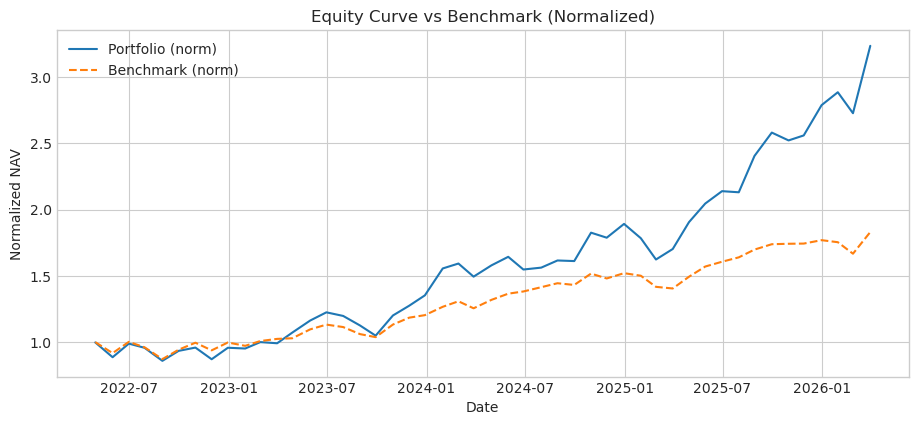

In [35]:
eq_plot = daily_eq.copy() if daily_eq is not None else eq.copy()
if daily_eq is not None:
    eq_plot['portfolio_nav_norm'] = eq_plot['portfolio_value'] / float(eq_plot['portfolio_value'].iloc[0])
    eq_plot['benchmark_nav_norm'] = eq_plot['benchmark_value'] / float(eq_plot['benchmark_value'].iloc[0])
    plot_title = 'Daily Portfolio Value vs Benchmark (Normalized)'
else:
    eq_plot['portfolio_nav_norm'] = eq_plot['nav'] / float(eq_plot['nav'].iloc[0])
    eq_plot['benchmark_nav_norm'] = (1.0 + pd.to_numeric(eq_plot['benchmark_return'], errors='coerce').fillna(0.0)).cumprod()
    plot_title = 'Equity Curve vs Benchmark (Normalized)'

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(eq_plot['trade_date'], eq_plot['portfolio_nav_norm'], label='Portfolio (norm)')
ax.plot(eq_plot['trade_date'], eq_plot['benchmark_nav_norm'], label='Benchmark (norm)', linestyle='--')
ax.set_title(plot_title)
ax.set_xlabel('Date')
ax.set_ylabel('Normalized NAV')
ax.legend()
plt.show()


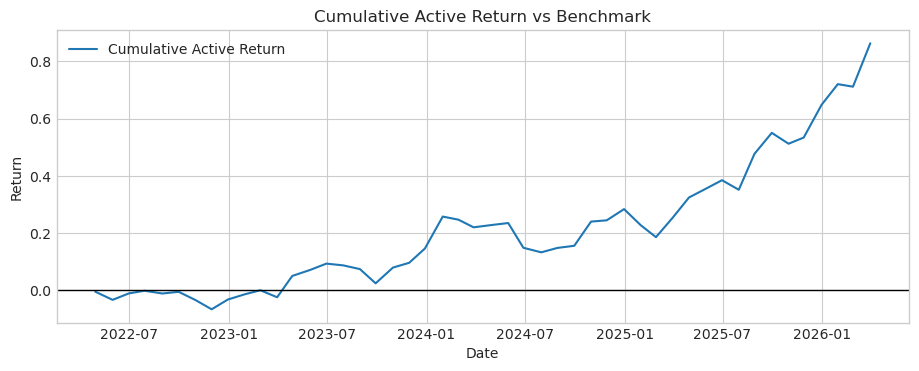

In [36]:
eq_plot = daily_eq.copy() if daily_eq is not None else eq.copy()
eq_plot['active_return'] = pd.to_numeric(eq_plot['portfolio_return'], errors='coerce').fillna(0.0) - pd.to_numeric(eq_plot['benchmark_return'], errors='coerce').fillna(0.0)
eq_plot['cum_active_return'] = (1.0 + eq_plot['active_return']).cumprod() - 1.0

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(eq_plot['trade_date'], eq_plot['cum_active_return'], label='Cumulative Active Return')
ax.axhline(0.0, color='black', linewidth=1)
ax.set_title('Cumulative Active Return vs Benchmark')
ax.set_xlabel('Date')
ax.set_ylabel('Return')
ax.legend()
plt.show()


In [37]:
cost_series = pd.to_numeric(eq['cost'], errors='coerce').fillna(0.0) if 'cost' in eq.columns else pd.Series(0.0, index=eq.index)
turnover_series = pd.to_numeric(eq['turnover'], errors='coerce').fillna(0.0) if 'turnover' in eq.columns else pd.Series(0.0, index=eq.index)
raw_turnover_series = pd.to_numeric(eq['raw_turnover'], errors='coerce').fillna(0.0) if 'raw_turnover' in eq.columns else pd.Series(0.0, index=eq.index)

execution_summary = pd.DataFrame([
    {'metric': 'rebalance_rows', 'value': int(len(eq))},
    {'metric': 'total_cost', 'value': float(cost_series.sum())},
    {'metric': 'avg_cost_per_rebalance', 'value': float(cost_series.mean()) if len(cost_series) else 0.0},
    {'metric': 'total_executed_turnover', 'value': float(turnover_series.sum())},
    {'metric': 'total_raw_turnover', 'value': float(raw_turnover_series.sum())},
])
display(execution_summary)

if orders_history is not None and len(orders_history) > 0:
    est_cost_col = pd.to_numeric(orders_history.get('estimated_cost', 0.0), errors='coerce').fillna(0.0)
    notional_col = pd.to_numeric(orders_history.get('notional', 0.0), errors='coerce').fillna(0.0)
    buys = int((orders_history.get('action', '') == 'BUY').sum()) if 'action' in orders_history.columns else 0
    sells = int((orders_history.get('action', '') == 'SELL').sum()) if 'action' in orders_history.columns else 0
    order_summary = pd.DataFrame([
        {'metric': 'orders_count', 'value': int(len(orders_history))},
        {'metric': 'buy_orders', 'value': buys},
        {'metric': 'sell_orders', 'value': sells},
        {'metric': 'gross_notional_traded', 'value': float(notional_col.abs().sum())},
        {'metric': 'net_notional_traded', 'value': float(notional_col.sum())},
        {'metric': 'orders_estimated_cost_total', 'value': float(est_cost_col.sum())},
    ])
    display(order_summary)
else:
    print('orders_history.csv not found for selected run.')


,metric,value
0,rebalance_rows,48.000000
1,total_cost,19167.182945
2,avg_cost_per_rebalance,399.316311
3,total_executed_turnover,25.055058
4,total_raw_turnover,40.729590


,metric,value
0,orders_count,5.305000e+03
1,buy_orders,1.870000e+03
2,sell_orders,3.435000e+03
3,gross_notional_traded,3.833437e+07
4,net_notional_traded,1.412109e-04
5,orders_estimated_cost_total,1.916718e+04


,metric,value
0,latest_trade_date,2026-03-31 00:00:00
1,positions_count,100
2,sum_weights,1.0
3,top_10_weight,0.464318
4,top_20_weight,0.702652
5,hhi,0.032535
6,effective_n,30.735998


,trade_date,symbol,weight
0,2026-03-31,NVDA,0.071844
1,2026-03-31,TSLA,0.063914
2,2026-03-31,SNDK,0.050442
3,2026-03-31,LITE,0.046949
4,2026-03-31,XOM,0.045930
5,2026-03-31,WDC,0.041751
6,2026-03-31,GEV,0.040218
7,2026-03-31,MU,0.037212
8,2026-03-31,JNJ,0.035618
9,2026-03-31,VZ,0.030440


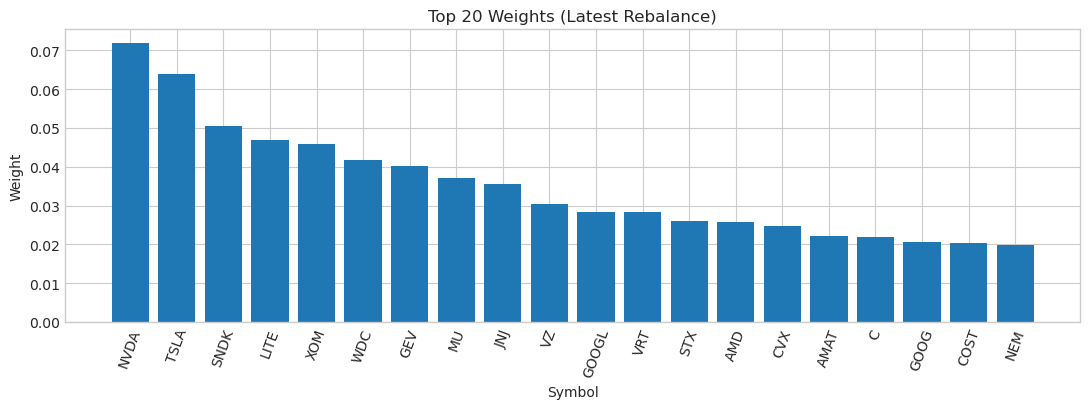

In [38]:
if weights_history is not None and len(weights_history) > 0:
    weight_cols = [c for c in weights_history.columns if c != 'trade_date']
    w_long = weights_history.melt(id_vars='trade_date', value_vars=weight_cols, var_name='symbol', value_name='weight')
    w_long['weight'] = pd.to_numeric(w_long['weight'], errors='coerce').fillna(0.0)
    w_long = w_long[w_long['weight'] > 0.0]
    name_map = map_symbols_to_stock_names(weight_cols, fallback_to_symbol=True)
    w_long['stock_name'] = w_long['symbol'].map(name_map).fillna(w_long['symbol'])
    latest_date = w_long['trade_date'].max()
    latest_w = w_long[w_long['trade_date'] == latest_date].sort_values('weight', ascending=False)
    prev_dates = sorted(d for d in w_long['trade_date'].unique() if d < latest_date)
    prev_date = prev_dates[-1] if prev_dates else None
    latest_total = float(latest_w['weight'].sum())
    hhi = float((latest_w['weight'] ** 2).sum())
    effective_n = (1.0 / hhi) if hhi > 0 else 0.0
    concentration = pd.DataFrame([
        {'metric': 'latest_trade_date', 'value': latest_date},
        {'metric': 'previous_trade_date', 'value': prev_date},
        {'metric': 'positions_count', 'value': int(len(latest_w))},
        {'metric': 'sum_weights', 'value': latest_total},
        {'metric': 'top_10_weight', 'value': float(latest_w['weight'].head(10).sum())},
        {'metric': 'top_20_weight', 'value': float(latest_w['weight'].head(20).sum())},
        {'metric': 'hhi', 'value': hhi},
        {'metric': 'effective_n', 'value': effective_n},
    ])
    display(concentration)
    display(latest_w[['stock_name', 'symbol', 'weight']].head(25).reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(11, 4.2))
    topn = latest_w.head(20)
    ax.bar(topn['stock_name'], topn['weight'])
    ax.set_title('Top 20 Weights (Latest Rebalance)')
    ax.set_xlabel('Stock Name')
    ax.set_ylabel('Weight')
    ax.tick_params(axis='x', rotation=70)
    plt.tight_layout()
    plt.show()

    if prev_date is not None:
        prev_w = w_long[w_long['trade_date'] == prev_date][['symbol', 'weight']].rename(columns={'weight': 'prev_weight'})
        latest_comp = latest_w[['symbol', 'weight']].rename(columns={'weight': 'latest_weight'})
        weight_changes = latest_comp.merge(prev_w, on='symbol', how='outer').fillna(0.0)
        weight_changes['stock_name'] = weight_changes['symbol'].map(name_map).fillna(weight_changes['symbol'])
        weight_changes['delta_weight'] = weight_changes['latest_weight'] - weight_changes['prev_weight']
        weight_changes['abs_delta_weight'] = weight_changes['delta_weight'].abs()
        weight_changes = weight_changes.sort_values('abs_delta_weight', ascending=False)
        display(weight_changes[['stock_name', 'symbol', 'latest_weight', 'prev_weight', 'delta_weight', 'abs_delta_weight']].head(25).reset_index(drop=True))

        fig, ax = plt.subplots(figsize=(11, 5.0))
        top_delta = weight_changes.head(20).sort_values('delta_weight')
        colors = ['#2ca02c' if v >= 0 else '#d62728' for v in top_delta['delta_weight']]
        ax.barh(top_delta['stock_name'], top_delta['delta_weight'], color=colors)
        ax.axvline(0.0, color='black', linewidth=1)
        ax.set_title('Top 20 Weight Changes (Latest vs Previous Rebalance)')
        ax.set_xlabel('Delta Weight')
        ax.set_ylabel('Stock Name')
        plt.tight_layout()
        plt.show()
    else:
        print('Only one rebalance snapshot is available; no weight-change comparison to display.')
else:
    print('weights_history.csv not found for selected run.')


,trade_date,orders_count,gross_notional,net_notional,estimated_cost
28,2024-08-30,100,8.079219e+05,-1.325379e-02,403.960961
29,2024-09-30,104,8.161832e+05,2.230127e-11,408.091582
30,2024-10-31,102,8.416674e+05,-1.587053e-02,420.833703
31,2024-11-29,102,9.119229e+05,-3.672094e-10,455.961457
32,2024-12-31,105,9.406648e+05,1.185099e-11,470.332422
33,2025-01-31,101,9.628764e+05,5.411045e-10,481.438208
34,2025-02-28,101,8.959663e+05,-1.665355e-02,447.983135
35,2025-03-31,103,8.229020e+05,1.236913e-10,411.451000
36,2025-04-30,99,8.498208e+05,-2.946763e-10,424.910389
37,2025-05-30,101,9.493399e+05,-1.818989e-11,474.669943


,trade_date,symbol,action,delta_weight,notional,estimated_cost
4882,2025-11-28,PLTR,SELL,-0.047866,-120198.180066,60.099090
2770,2024-03-28,AMZN,SELL,-0.075427,-119758.243554,59.879122
5204,2026-02-27,WBD,SELL,-0.041081,-118005.330353,59.002665
2668,2024-02-29,AMZN,BUY,0.074657,115781.220708,57.890610
5106,2026-01-30,XOM,BUY,0.034157,94811.620419,47.405810
4714,2025-10-31,AMD,BUY,0.034836,89524.123576,44.762062
5081,2026-01-30,PM,BUY,0.031133,86417.229651,43.208615
4814,2025-11-28,AMD,SELL,-0.033214,-83405.517967,41.702759
5190,2026-02-27,SNDK,BUY,0.028922,83078.096565,41.539048
4464,2025-07-31,MSFT,BUY,0.038253,81498.933801,40.749467


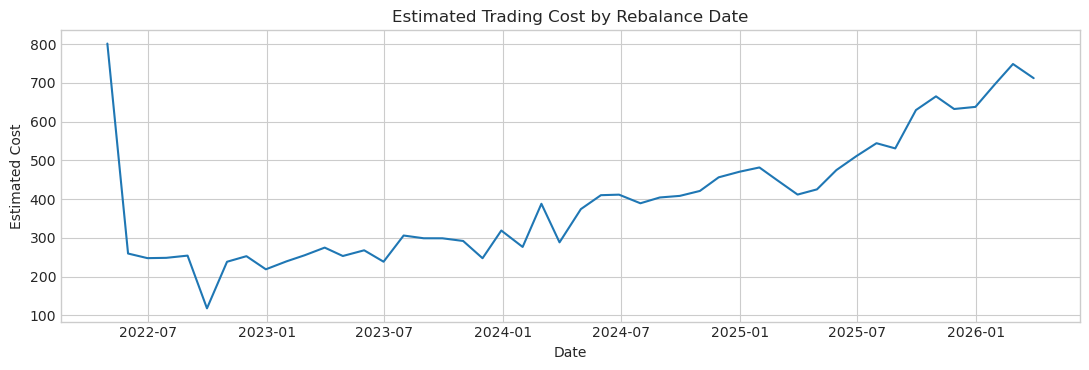

In [39]:
if orders_history is not None and len(orders_history) > 0 and 'trade_date' in orders_history.columns:
    o = orders_history.copy()
    o['notional'] = pd.to_numeric(o.get('notional', 0.0), errors='coerce').fillna(0.0)
    o['estimated_cost'] = pd.to_numeric(o.get('estimated_cost', 0.0), errors='coerce').fillna(0.0)
    order_name_map = map_symbols_to_stock_names(o['symbol'].dropna().unique(), fallback_to_symbol=True)
    o['stock_name'] = o['symbol'].map(order_name_map).fillna(o['symbol'])
    daily_orders = o.groupby('trade_date', as_index=False).agg(
        orders_count=('symbol', 'size'),
        gross_notional=('notional', lambda x: float(x.abs().sum())),
        net_notional=('notional', 'sum'),
        estimated_cost=('estimated_cost', 'sum'),
    ).sort_values('trade_date')
    display(daily_orders.tail(20))

    largest_orders = o.assign(abs_notional=o['notional'].abs()).sort_values('abs_notional', ascending=False)
    display(largest_orders[['trade_date', 'stock_name', 'symbol', 'action', 'delta_weight', 'notional', 'estimated_cost']].head(25))

    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.plot(daily_orders['trade_date'], daily_orders['estimated_cost'])
    ax.set_title('Estimated Trading Cost by Rebalance Date')
    ax.set_xlabel('Date')
    ax.set_ylabel('Estimated Cost')
    plt.tight_layout()
    plt.show()
else:
    print('orders_history.csv not found or missing trade_date column.')
